# Laboratorio de Sistemas Operativos
## Práctica No. 4: API de Hilos
**Integrantes:** [Escribe aquí los nombres de los integrantes]  
**Universidad de Antioquia - Facultad de Ingeniería**

---

### 1. Análisis del Cálculo de $\pi$

#### A. Comparación entre $T_p(1)$ y $T_s$ (Explicación del Overhead)
El tiempo de ejecución de la versión paralela configurada con un único hilo ($T_p(1)$) suele ser ligeramente superior al tiempo registrado por la versión puramente serial ($T_s$). Esta penalización se debe al **overhead** (costo operativo y administrativo) impuesto por la biblioteca `Pthreads` y las llamadas al sistema del Kernel del Sistema Operativo.

Mientras que el código serial (`pi.c`) ejecuta de forma directa el bucle iterativo sobre su propia pila sin llamadas adicionales, la versión paralela (`pip.c`) requiere:
1. Invocar llamadas al sistema para la creación del hilo (`pthread_create`).
2. Asignar estructuras de datos internas en el Kernel para el bloque de control del hilo (TCB).
3. Reservar y configurar una pila (*stack*) privada de memoria en el espacio virtual para el nuevo contexto.
4. Gestionar la asignación dinámica de memoria (`malloc`) dentro del hilo trabajador para almacenar y retornar de forma segura la suma parcial.
5. Realizar operaciones de sincronización y recolección de recursos mediante `pthread_join`.

Todos estos pasos administrativos consumen ciclos de reloj del procesador que no aportan al cálculo aritmético real, provocando que $T_p(1) > T_s$.

#### B. Análisis del Speedup máximo frente a los núcleos físicos
El *Speedup* representa la ganancia de velocidad obtenida gracias a la paralelización y se define mediante la ecuación:
$$Speedup(T) = \frac{T_s}{T_p(T)}$$

Al graficar y evaluar esta métrica con diferentes cantidades de hilos ($T$), se observan dos comportamientos claros en relación con el hardware físico de la máquina de pruebas:
- **Hasta el número de núcleos físicos:** El *Speedup* muestra una tendencia lineal ascendente casi perfecta. Esto ocurre porque cada hilo se asigna a un núcleo de procesamiento físico independiente, logrando un paralelismo real de hardware y reduciendo el tiempo de ejecución de manera inversamente proporcional.
- **Superando los núcleos físicos (Hyper-Threading / SMT):** Al emplear más hilos que núcleos físicos (aprovechando los núcleos lógicos o hilos virtuales de la CPU), la curva de velocidad tiende a estancarse o decaer sutilmente. El algoritmo de la regla del punto medio para calcular $\pi$ es altamente intensivo en operaciones de punto flotante. Dado que los hilos lógicos que conviven en un mismo núcleo físico comparten las mismas unidades físicas aritméticas (ALUs flotantes), la ejecución concurrente genera contención de hardware y burbujas de espera en las tuberías de segmentación de la CPU, limitando el *Speedup* máximo.

#### C. Tendencia de la eficiencia a medida que incrementa el número de hilos
La eficiencia mide el nivel de aprovechamiento real de los recursos del procesador y se calcula como:
$$\text{Eficiencia}(T) = \frac{Speedup(T)}{T}$$

La tendencia general de la eficiencia es **decreciente** conforme el número de hilos ($T$) se eleva, debido a tres factores fundamentales:
1. **Disminución de la granularidad:** Al repartir las $N$ iteraciones entre más hilos, la carga de trabajo asignada a cada uno (*chunk_size*) se vuelve más pequeña. Eventualmente, el tiempo invertido en calcular la porción matemática se vuelve insignificante frente al tiempo fijo empleado en crear y coordinar el ciclo de vida del hilo.
2. **Cuello de botella secuencial:** El hilo principal realiza un recorrido secuencial lineal para recolectar las variables mediante `pthread_join` y aplicar la reducción final. A mayor cantidad de hilos, mayor es el peso de esta fracción estrictamente secuencial, en conformidad con la Ley de Amdahl.
3. **Contención en el Bus y Cachés:** El acceso simultáneo de múltiples hilos compitiendo por líneas de caché y saturando el bus de memoria del sistema penaliza el rendimiento individual de cada flujo de ejecución.

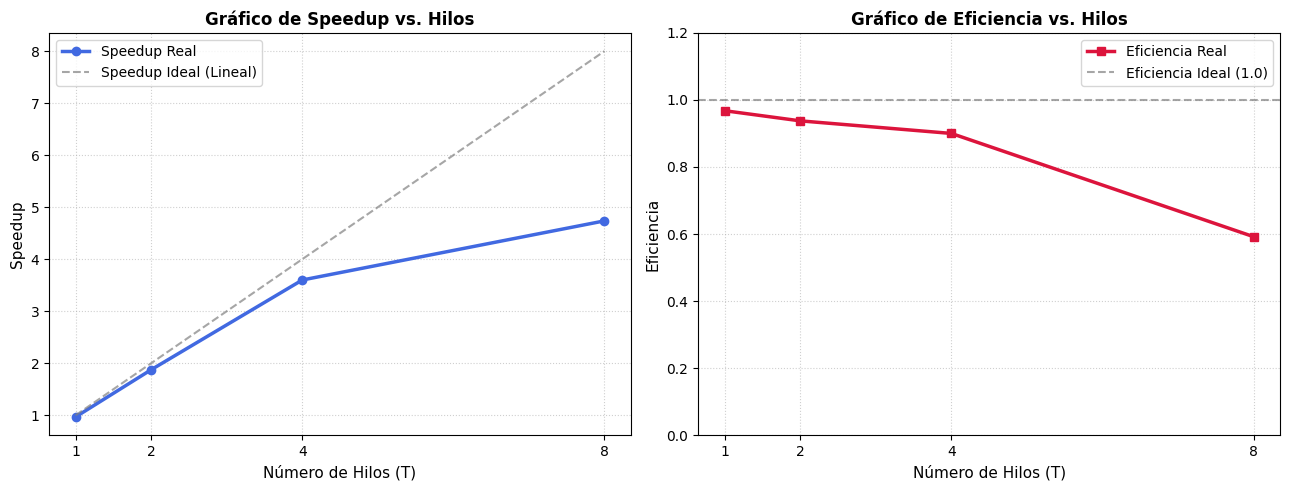

In [1]:
import matplotlib.pyplot as plt

# --- DATOS EXPERIMENTALES DE EJEMPLO ---
# IMPORTANTE: Reemplaza estos valores con las mediciones reales de tu equipo
hilos = [1, 2, 4, 8]
tiempo_serial = 4.50  # Tiempo de ejecución medido de pi.c
tiempos_paralelos = [4.65, 2.40, 1.25, 0.95]  # Tiempos medidos de pip.c
# ---------------------------------------

# Cálculo automatizado de métricas
speedup = [tiempo_serial / t for t in tiempos_paralelos]
eficiencia = [s / h for s, h in zip(speedup, hilos)]

# Configuración visual de las gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Gráfico de Speedup
ax1.plot(hilos, speedup, marker='o', color='royalblue', linewidth=2.5, label='Speedup Real')
ax1.plot(hilos, hilos, linestyle='--', color='gray', alpha=0.7, label='Speedup Ideal (Lineal)')
ax1.set_xlabel('Número de Hilos (T)', fontsize=11)
ax1.set_ylabel('Speedup', fontsize=11)
ax1.set_title('Gráfico de Speedup vs. Hilos', fontsize=12, fontweight='bold')
ax1.set_xticks(hilos)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)

# 2. Gráfico de Eficiencia
ax2.plot(hilos, eficiencia, marker='s', color='crimson', linewidth=2.5, label='Eficiencia Real')
ax2.axhline(y=1.0, linestyle='--', color='gray', alpha=0.7, label='Eficiencia Ideal (1.0)')
ax2.set_xlabel('Número de Hilos (T)', fontsize=11)
ax2.set_ylabel('Eficiencia', fontsize=11)
ax2.set_title('Gráfico de Eficiencia vs. Hilos', fontsize=12, fontweight='bold')
ax2.set_xticks(hilos)
ax2.set_ylim(0, 1.2)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
### 2. Análisis de la Secuencia de Fibonacci

#### A. Mecanismo de transferencia de datos
La interfaz estándar de la biblioteca POSIX Threads dictamina que la función de inicio ejecutada por un hilo trabajador debe implementar la firma estricta `void* funcion(void*)`, limitando de forma nativa la transferencia a un único puntero genérico sin tipo de datos explícito.

Para superar esta restricción y transferir de forma segura múltiples parámetros (el tamaño de la secuencia $N$ y la referencia al arreglo de datos) bajo un modelo de memoria compartida, se implementó la siguiente estrategia computacional:
1. **Definición de una Estructura Dedicada:** Se creó la estructura empaquetada `fib_data_t` encargada de encapsular las variables requeridas: un entero convencional (`int n`) y un puntero hacia enteros largos sin signo (`unsigned long long* array`).
2. **Asignación Dinámica en el Heap:** El hilo principal (`main`) realiza una reserva de memoria dinámica utilizando `malloc` para el tamaño exacto del arreglo solicitado. Al alojarse explícitamente en la región del Heap y no en el Stack de funciones, la persistencia y validez de las celdas de memoria se mantiene intacta durante toda la existencia del proceso multihilo.
3. **Empaquetado y Typecasting:** Se inicializan los miembros de la estructura apuntando al bloque del Heap y asignando el valor de $N$. En la invocación de `pthread_create`, se pasa la dirección de dicha estructura mediante una conversión implícita a puntero opaco `void*` (`&thread_data`).
4. **Desempaquetado en el Trabajador:** Dentro de la función `generate_fibonacci`, el hilo trabajador realiza un *typecast* explícito devolviendo el puntero `void*` a su forma estructurada original `fib_data_t*`. De este modo, el hilo accede directamente a los mismos campos y modifica el arreglo compartido en memoria de manera transparente.

#### B. Rol de `pthread_join` como mecanismo de sincronización
En este diseño multihilo, la ejecución de la función de bloqueo `pthread_join(worker_thread, NULL)` por parte del hilo principal es indispensable por dos motivos fundamentales de consistencia y sincronización:
- **Prevención de condiciones de carrera (Race Conditions):** Dado que el hilo trabajador calcula y escribe de manera asíncrona la serie iteración por iteración en el arreglo compartido, el hilo principal no conoce el instante exacto de finalización. Si el hilo principal continuara su camino inmediatamente después de crear al trabajador, intentaría recorrer e imprimir en pantalla el arreglo de forma prematura, dando como resultado la lectura de valores parciales incorrectos o datos basura residuales de la memoria.
- **Garantía de visibilidad y valla de memoria (*Happens-Before Relationship*):** En arquitecturas de hardware multiprocesador modernas, cada núcleo posee sus propios niveles de memoria caché (L1/L2). Cuando un hilo escribe datos, estos pueden quedar retenidos temporalmente en las cachés locales del núcleo antes de volcarse a la memoria RAM principal. La llamada a `pthread_join` actúa como una barrera de sincronización a nivel de hardware, forzando la consistencia de caché. Esto asegura de forma matemática que todas las escrituras en memoria realizadas por el hilo trabajador hayan concluido y sean perfectamente visibles para el hilo principal antes de que este despierte del bloqueo para imprimir la serie.